# Task 1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = "mps"

### Dataset

In [2]:
torch.manual_seed(42)

n = 1000
u = torch.randn(n, 1)
v = torch.randn(n, 1)

x1 = u
x2 = 0.5 * u + v
x3 = 2.0 * u - 0.3 * v + 0.1 * torch.randn(n, 1)

X = torch.cat([x1, x2, x3], dim=1)
X = X - X.mean(dim=0, keepdim=True)


### AE

In [3]:
class LinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(3, 2)
        self.decoder = nn.Linear(2, 3)
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

### prosty trening

In [ ]:
model = LinearAE()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
epochs = 100000

for epoch in range(epochs):
    optimizer.zero_grad()
    reconstructed, _ = model(X)
    loss = criterion(reconstructed, X)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

### PCA

In [6]:
pca = PCA(n_components=2)
X_np = X.detach().numpy()
X_pca_latent = pca.fit_transform(X_np)
X_pca_reconstructed = pca.inverse_transform(X_pca_latent)

ae_mse = losses[-1]
pca_mse = ((X_np - X_pca_reconstructed) ** 2).mean()

### Błąd rekonstrukcji

In [7]:
print(f"LAE MSE: {ae_mse:.6f}")
print(f"PCA MSE: {pca_mse:.6f}")

LAE MSE: 0.000579
PCA MSE: 0.000579


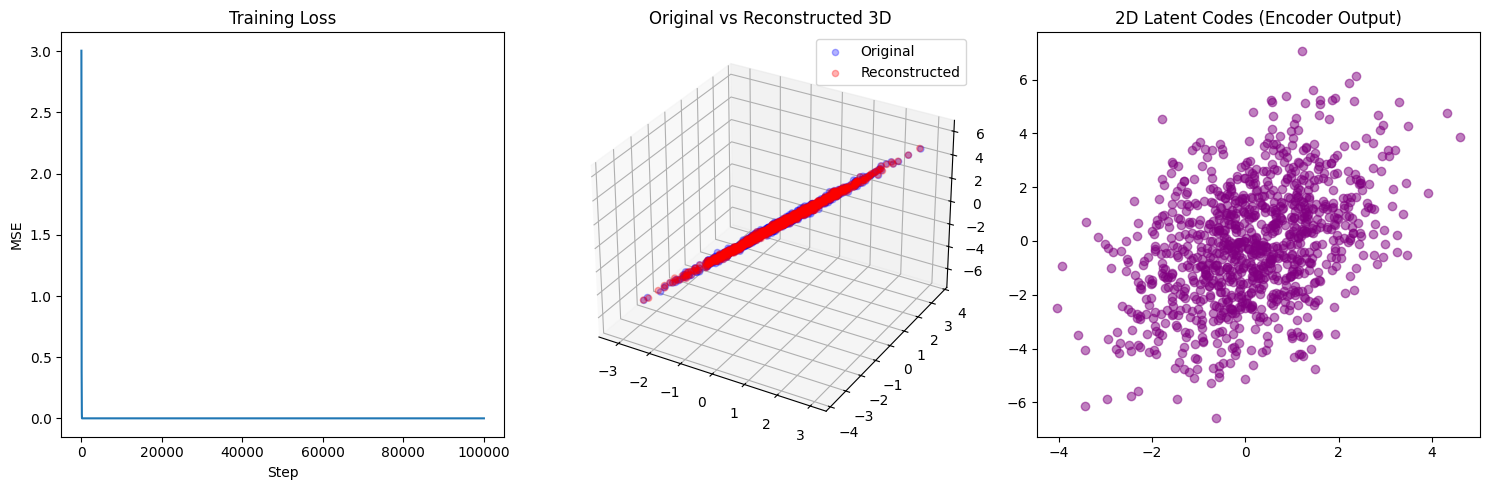

In [8]:
_, Z_ae = model(X)
Z_ae = Z_ae.detach().numpy()
X_rec = reconstructed.detach().numpy()

fig = plt.figure(figsize=(15, 5))

# Plot 1: Loss
ax1 = fig.add_subplot(131)
ax1.plot(losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE")

# Plot 2: Original vs Reconstructed (3D)
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2], alpha=0.3, label='Original', c='blue')
ax2.scatter(X_rec[:, 0], X_rec[:, 1], X_rec[:, 2], alpha=0.3, label='Reconstructed', c='red')
ax2.set_title("Original vs Reconstructed 3D")
ax2.legend()

# Plot 3: Latent Space
ax3 = fig.add_subplot(133)
ax3.scatter(Z_ae[:, 0], Z_ae[:, 1], alpha=0.5, c='purple')
ax3.set_title("2D Latent Codes (Encoder Output)")

plt.tight_layout()
plt.show()

* What the encoder learns: Enkoder uczy się rzutować  3-wymiarowe dane na 2-wymiarową podprzestrzeń. Dokładnie to macierz wag enkodera definiuje wektory bazowe tej nowej podprzestrzeni.

* What the decoder learns: Dekoder uczy się liniowego przekształcenia tych już 2-wymiarowych cech, aby z powrotem odtworzyć punkty w oryginalnej przestrzeni trójwymiarowej.

* Why the bottleneck forces compression: Liniowe przeszktałcenie do przestrzeni o mniejszym wymiarze nie może być różnowarotściowe, tracimy infromacje 

* Why the result should be similar to PCA: PCA robi niemal identyczną rzecz, szuka hiperprzestrzeni rozpiannej przez wektory o najwiekszej wariancji danych (najbardziej informatywne)

* Why latent coordinates do not have to be identical: PCA korzysta z macierzy kowarniacji, w której wektowy własne wyznaczają kierunki największej wariancji, one są zawsze orotgonlane (tw spektralne). W LAE nie mamy takiej własności.

* Reconstruction errors: Błąd rekonstrukcji powinien być w dwóch metoda podobny i taki jest

# Task 2

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [10]:
def add_noise(x, noise_std=0.3):
    noise = torch.randn_like(x) * noise_std
    x_noisy = x + noise
    x_noisy = torch.clamp(x_noisy, 0.0, 1.0)
    return x_noisy

class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Wymiary na wejściu: (1, 28, 28)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # (16, 14, 14)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # (32, 7, 7)
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # (16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # (1, 28, 28)
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device, noise_std):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_noise(clean, noise_std=noise_std)

        optimizer.zero_grad()
        reconstructed = model(noisy)
        # wejściem był obraz zaszumiony, ale targetem jest obraz CZYSTY (denoising)
        loss = criterion(reconstructed, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * clean.size(0)
        total_samples += clean.size(0)

    return total_loss / total_samples

In [12]:
model_dae = ConvDenoisingAE().to(device)
criterion_dae = nn.MSELoss()
optimizer_dae = optim.Adam(model_dae.parameters(), lr=0.001)

epochs = 5
noise_level = 0.5
dae_losses = []

print(f"Training Denoising AE with noise_std = {noise_level}")
for epoch in range(epochs):
    loss = train_one_epoch(model_dae, train_loader, optimizer_dae, criterion_dae, device, noise_level)
    dae_losses.append(loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Training Denoising AE with noise_std = 0.5
Epoch 1/5, Loss: 0.0395
Epoch 2/5, Loss: 0.0211
Epoch 3/5, Loss: 0.0202
Epoch 4/5, Loss: 0.0197
Epoch 5/5, Loss: 0.0193


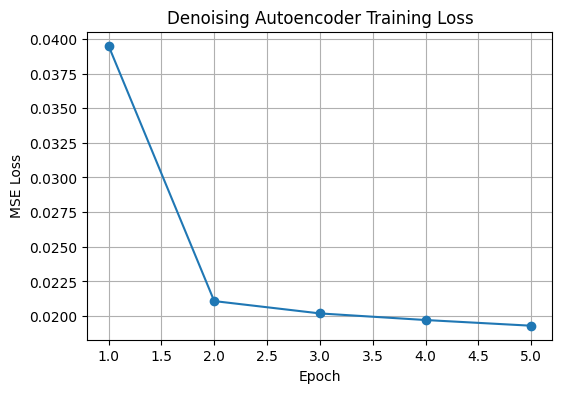

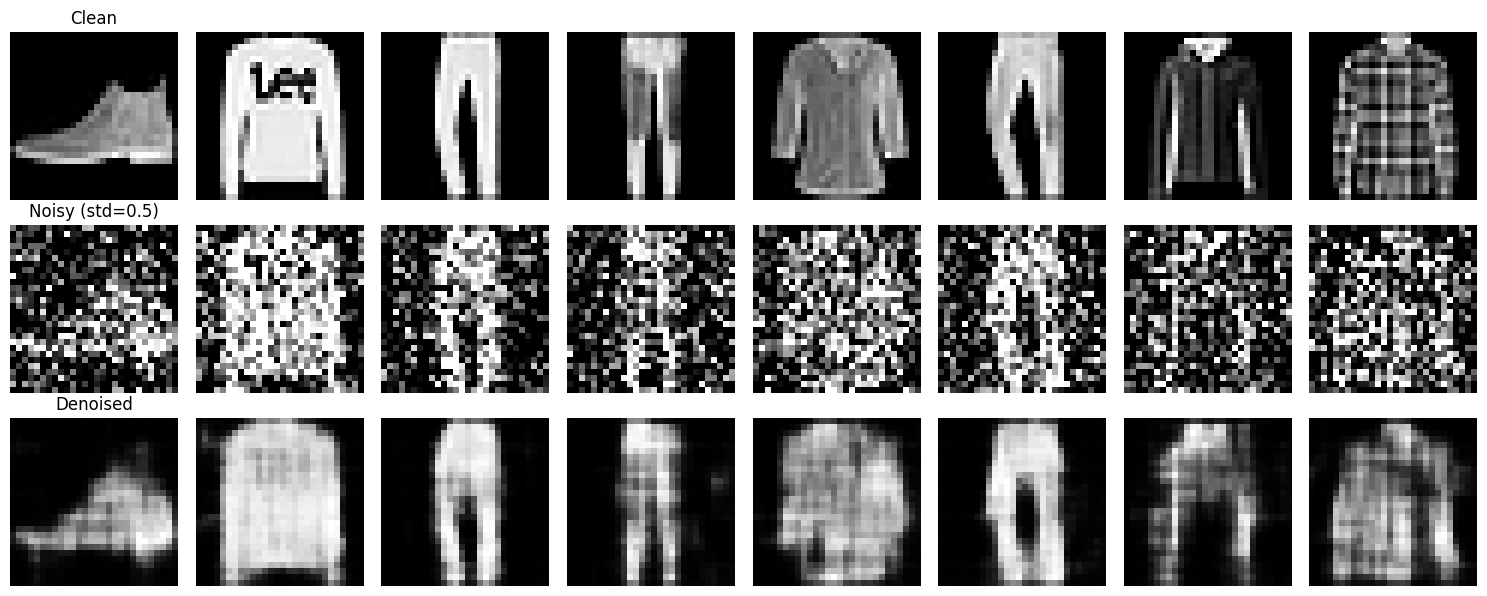

In [13]:
# Wykres funkcji straty
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), dae_losses, marker='o')
plt.title("Denoising Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# Wizualizacja 8 przykładów obrazków testowycb
model_dae.eval()
test_images, _ = next(iter(test_loader))
test_images = test_images[:8].to(device)
noisy_test = add_noise(test_images, noise_std=noise_level)

with torch.no_grad():
    reconstructed_test = model_dae(noisy_test)

fig, axes = plt.subplots(3, 8, figsize=(15, 6))
for i in range(8):
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Clean")
    
    axes[1, i].imshow(noisy_test[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title(f"Noisy (std={noise_level})")
    
    axes[2, i].imshow(reconstructed_test[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Denoised")

plt.tight_layout()
plt.show()

* Why this is still an autoencoder:  
 Nie jest już to tak porsty model, ale realizuje to samo zadanie, "rzutuje" dane na mniejszą przestrzeń nastepnie je odzyskuje. Warstwy konwolucyjne mają pomóc modelowi uczyć się cech obrazka.

* Why the input and target are different:
 Nie chcemy żeby model się przeuczył. Używamy zaszumionego obrazka jako wejscie aby zmusic model do nauki isotonych czech.

* What the latent representation contains:
    Docelowo - najistotniejsz cechy 
* Why very large noise makes the task harder:
  Klascznym problemem jest to, że szum przeważa nad oryginalnym sygnałem, nie możemy dobrać sie do istotnych informacji.
* Whether the model removes noise or also blurs some details:
  Model usuwa szum, ale kosztem drobnych szczegółów, co naturalnie wprowada pewien blur na obraz, tracą ostrość

# Task 3

## A

Dywergencję Kullbacka-Leiblera ($D_{KL}$) dla rozkładów normalnych 1D

$$D_{KL}(q\|p) = \log\frac{\sigma_p}{\sigma_q} + \frac{\sigma_q^2 + (\mu_q - \mu_p)^2}{2\sigma_p^2} - \frac{1}{2}$$

Calculate the following by hand or using Python:


1. $q = \mathcal{N}(0, 1)$, $p = \mathcal{N}(0, 1)$
2. $q = \mathcal{N}(1, 1)$, $p = \mathcal{N}(0, 1)$
3. $q = \mathcal{N}(0, 0.5^2)$, $p = \mathcal{N}(0, 1)$
4. $q = \mathcal{N}(0, 2^2)$, $p = \mathcal{N}(0, 1)$

Create a table with columns:

1. $\mathbf{0}$, to te same rozkłady
2. $\mathbf{\frac{1}{2}}$, bo zostaje tylko czynnik z różnicą średnich
3. $\log(1/0.5) + (0.5^2 + 0)/2 - 0.5 = \log(2) + 0.25/2 - 0.5 \approx 0.693 + 0.125 - 0.5 = \mathbf{0.318}$
4. $\log(1/2) + (2^2 + 0)/2 - 0.5 = \log(0.5) + 4/2 - 0.5 \approx -0.693 + 2 - 0.5 = \mathbf{0.807}$

1. 0
2. 0.5
3. ~0.318
4. ~0.807

## B

In [28]:
def kl_standard_normal(mu, logvar):
    """
    mu: tensor of shape (batch_size, latent_dim)
    logvar: tensor of shape (batch_size, latent_dim)
    returns: tensor of shape (batch_size,)
    """
    # Wzór: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl

# Testowanie z przykładami z zadania
mu = torch.tensor([[0.0, 0.0],
                   [1.0, 0.0],
                   [0.0, 2.0]])

logvar = torch.tensor([[0.0, 0.0],
                       [0.0, 0.0],
                       [0.0, 0.0]])

results = kl_standard_normal(mu, logvar)
print("Wyniki KL:")
for i, val in enumerate(results):
    print(f"Przykład {i+1}: {val.item():.4f}")

Wyniki KL:
Przykład 1: -0.0000
Przykład 2: 0.5000
Przykład 3: 2.0000


### Wyjaśnienie wyników

KL reperezentuje "koszt" informacyjny, jaki ponosimy próbując dopasować rozkład ukryty $q_\phi(z|x)$ do rozkładu a priori $p(z) = \mathcal{N}(0, I)$.

1.  Wynik 0.0 oznacza, że rozkład enkodera jest identyczny ze standardowym rozkładem normalnym. W tym przypadku nie ma żadnej straty informacji.

2. Wzrost wartości KL wynika z przesunięcia średniej. Ponieważ odległość od centrum rozkładu $\mathcal{N}(0, I)$ zwiększyła się, enkoder musi "zapłacić" cenę w funkcji kosztu za to, że jego rozkład nie pokrywa się z priorem.

3. Podobnie jak w poprzednim przypadku, każda odchyłka od założeń $\mathcal{N}(0, I)$ (zarówno w średniej $\mu$, jak i wariancji $\sigma^2$) zwiększa dywergencję KL.


## C

In [29]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z

In [30]:
mu_target = 5.0
std_target = 2.0

logvar_target = torch.tensor([torch.log(torch.tensor(std_target**2))])

mu = torch.tensor([mu_target])
logvar = logvar_target

samples = torch.stack([reparameterize(mu, logvar) for _ in range(10000)])

print(f"Empiryczna Średnia: {samples.mean().item():.4f} (Oczekiwano: ~{mu_target})")
print(f"Empiryczna Odchylenie Std: {samples.std().item():.4f} (Oczekiwano: ~{std_target})")

Empiryczna Średnia: 5.0283 (Oczekiwano: ~5.0)
Empiryczna Odchylenie Std: 2.0129 (Oczekiwano: ~2.0)


### Dlaczego ten trik jest użyteczny w uczeniu sieci neuronowych?

Standardowy proces uczenia sieci neuronowych opiera się na backpropagation, która wymaga obliczenia pochodnych funkcji kosztu względem parametrów modelu (tutaj $\mu$ i $\sigma$).

* Problem: 
Nie mamy czegoś takiego jak pochodna ze zmiennej losowej. 

* Rozwiązanie: 
Po prostu wprowadzamy szum pozan strukturę sieci. Oczywsita równość rozkładów.

Teraz sieć neurowonoa może optymazilować parametry rozkładów.
